In [2]:
import ipywidgets as widgets
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from PIL import Image
import json

In [3]:
path = "viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage1/DataComp"
fs = pa.hdfs.connect(user='mpi')
files = fs.ls(path)
files = [x for x in files if x.endswith("parquet")]

/tmp/ipykernel_61420/3280897918.py:2: FutureWarning: pyarrow.hdfs.connect is deprecated as of 2.0.0, please use pyarrow.fs.HadoopFileSystem instead.
  fs = pa.hdfs.connect(user='mpi')
25/01/16 05:09:48 INFO speed4j pool-simple-buffer-trigger-thread-[perf]: Statistics from 2025-01-16 05:08:48 to 2025-01-16 05:09:48
25/01/16 05:09:48 INFO speed4j pool-simple-buffer-trigger-thread-[perf]: Tag                                                           Avg(ms)      Min      Max  Std Dev     95th     99th   99.5th   Count
25/01/16 05:09:48 INFO speed4j pool-simple-buffer-trigger-thread-[perf]: dataarch.hdfs.luoxinchen.mpi.17185-dtmachine.2.6.0U60.3.4-cdh5.10.0-CLIENT-RELEASE.hadoop-lt-cluster     0.00     0.00     0.00     0.00     0.00     0.00     0.00       1
25/01/16 05:09:48 INFO speed4j pool-simple-buffer-trigger-thread-[perf]: 
25/01/16 05:09:48 WARN util.NativeCodeLoader main: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/01/1

In [4]:
x = np.random.choice(files)
print(x)
df = pq.read_table(x).to_pandas()

viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage1/DataComp/rank-1033-997f9f66-d272-11ef-81fe-946daee91740.parquet


25/01/16 05:10:21 WARN hdfs.DFSClient Thread-15: hedgedFetchBlockByteRange waited 50ms to read from DatanodeInfoWithStorage[10.85.123.21:50010,DS-23e8bf76-b9ae-48cf-9bd3-deb190885594,DISK] LocatedBlock{BP-1375695010-10.80.51.153-1669032439483:blk_81605637046_80614952818; getBlockSize()=261404544; corrupt=false; offset=268435456; activeIndex=2; locs=[DatanodeInfoWithStorage[10.85.123.21:50010,DS-23e8bf76-b9ae-48cf-9bd3-deb190885594,DISK], DatanodeInfoWithStorage[10.80.112.25:50010,DS-41325959-a2dc-4352-bb99-829d3b1f7ad2,DISK]]} 261339008 65536; spawning hedged read
25/01/16 05:10:22 WARN hdfs.DFSClient Thread-19: hedgedFetchBlockByteRange waited 50ms to read from DatanodeInfoWithStorage[10.82.243.181:50010,DS-cf0ffdbb-f9da-4f44-b352-7a755fa428a4,DISK] LocatedBlock{BP-1375695010-10.80.51.153-1669032439483:blk_81605613697_80614929469; getBlockSize()=268435456; corrupt=false; offset=0; activeIndex=2; locs=[DatanodeInfoWithStorage[10.82.243.181:50010,DS-cf0ffdbb-f9da-4f44-b352-7a755fa428a4,

images 1
source DataComp messages [{'role': 'user', 'content': [{'type': 'image', 'image': 'jpg'}, {'type': 'text', 'text': 'Please observe this image carefully and generate a brief description for it.'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Ebitus  Terrific Small Business Invoice Software  Workingpoint With Remarkable Basic Invoice Template Excel Besides Manufacturer Invoice Furthermore Client Invoice Template With Easy On The Eye Mazda Cx Invoice Also Dealer Cost Vs Invoice In Addition Invoice Books Custom And Motorcycle Invoice As Well As Toyota Tacoma Invoice Additionally Lawyer Invoice From Workingpointcom With Ebitus  Remarkable Small Business Invoice Software  Workingpoint With Easy On The Eye Basic Invoice Template Excel Besides Manufacturer Invoice Furthermore Client Invoice Template And Terrific Mazda Cx Invoice Also Dealer Cost Vs Invoice In Addition Invoice Books Custom From Workingpointcom.'}]}] segments None


'jpg'

(449, 473)

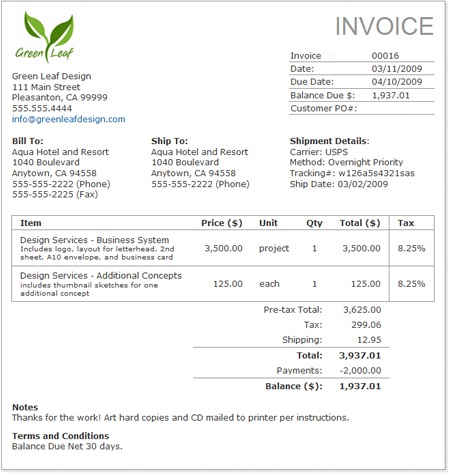

In [20]:
def decode_base64_image(base64_string):
    # 解码base64字符串并返回PIL图像对象
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    return image
    
def display_sample(sample):
    images = json.loads(sample.pop('images'))
    print('images', len(images))
    messages = json.loads(sample['messages'])
    segments = json.loads(sample['segments'])
    print('source', sample['source'], 'messages', messages, 'segments', segments)
    for name, base64_string in images.items():
        image = decode_base64_image(base64_string)
        display(name, image.size, image)

display_sample(df.sample().iloc[0].to_dict())